# Questão 1 - EDA

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import sqlite3
import matplotlib.pyplot as plt
import duckdb
from IPython.display import Image, display

### Caminho base do projeto

In [2]:
BASE_PATH = Path().resolve()

while BASE_PATH.name != "lh-nautical-data-project":
    BASE_PATH = BASE_PATH.parent

print(f"BASE PATH: {BASE_PATH}")

BASE PATH: /Users/richardgomes/lh-nautical-data-project


Carregando os dados em um dataframe Pandas para melhor visulização. 

In [3]:
DATA_PATH = BASE_PATH / "data"

RAW_PATH = DATA_PATH / "raw"
STAGING_PATH = DATA_PATH / "staging"
INTERMEDIATE_PATH = DATA_PATH / "intermediate"
MARTS_PATH = DATA_PATH / "marts"

SQL_PATH = BASE_PATH / "sql"
IMAGES_PATH = BASE_PATH / "imagens"

In [4]:
df_vendas = pd.read_csv(RAW_PATH / "vendas_2023_2024.csv", encoding="utf-8")

Parte 1 - Visão geral do dataset

In [5]:
conn = sqlite3.connect(':memory:')

In [6]:
df_vendas.to_sql('vendas', conn, index=False, if_exists='replace')

9895

Quantidade total de linhas

In [7]:
query = """
SELECT COUNT(*) AS total_linhas
FROM vendas
"""

pd.read_sql(query, conn)

,total_linhas
0,9895


Quantidade total de colunas

In [8]:
query = """
SELECT COUNT(*) AS total_colunas
FROM pragma_table_info('vendas')
"""

pd.read_sql(query, conn)

,total_colunas
0,6


Intervalo d e datas analisado (data mínima e
máxima)

In [9]:
df_vendas.columns

Index(['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date'], dtype='str')

In [10]:
query = """
SELECT 
    MIN(sale_date) AS data_min,
    MAX(sale_date) AS data_max
FROM vendas
"""

pd.read_sql(query, conn)

,data_min,data_max
0,01-01-2023,31-12-2024


 Questão 1.1 - SQL
Código calculando:
• Quantidade total d e linhas
• Quantidade total de colunas
• Intervalo de datas analisado (data mínima e máxima)
• Valor mínimo
• Valor máximo
• Valor médio

Query resposta:

In [11]:
"""
SELECT 
    COUNT(*) AS total_linhas,
    (SELECT COUNT(*) FROM pragma_table_info('vendas')) AS total_colunas,
    MIN(sale_date) AS data_min,
    MAX(sale_date) AS data_max,
    MIN(total) AS valor_min,
    MAX(total) AS valor_max,
    AVG(total) AS valor_medio
FROM vendas
"""


"\nSELECT \n    COUNT(*) AS total_linhas,\n    (SELECT COUNT(*) FROM pragma_table_info('vendas')) AS total_colunas,\n    MIN(sale_date) AS data_min,\n    MAX(sale_date) AS data_max,\n    MIN(total) AS valor_min,\n    MAX(total) AS valor_max,\n    AVG(total) AS valor_medio\nFROM vendas\n"

In [12]:
query = """
SELECT 
    COUNT(*) AS total_linhas,
    (SELECT COUNT(*) FROM pragma_table_info('vendas')) AS total_colunas,
    MIN(sale_date) AS data_min,
    MAX(sale_date) AS data_max,
    MIN(total) AS valor_min,
    MAX(total) AS valor_max,
    AVG(total) AS valor_medio
FROM vendas
"""

pd.read_sql(query, conn)

,total_linhas,total_colunas,data_min,data_max,valor_min,valor_max,valor_medio
0,9895,6,01-01-2023,31-12-2024,294.5,2222973.0,263797.828267


Questão 1.2 - Validação
Qual é o valor máximo registrado na coluna "total"?

In [13]:
query = """
SELECT MAX(total) AS valor_maximo
FROM vendas;
"""
pd.read_sql(query, conn)

,valor_maximo
0,2222973.0


Questão 1.3 - Interpretação
Com base na análise exploratória real

In [14]:
df_vendas['total'].describe()

count    9.895000e+03
mean     2.637978e+05
std      3.900072e+05
min      2.945000e+02
25%      2.313820e+04
50%      8.222500e+04
75%      3.390945e+05
max      2.222973e+06
Name: total, dtype: float64

In [15]:
df_vendas.isnull().sum()

id            0
id_client     0
id_product    0
qtd           0
total         0
sale_date     0
dtype: int64

In [16]:
df_vendas.duplicated().sum()

np.int64(0)

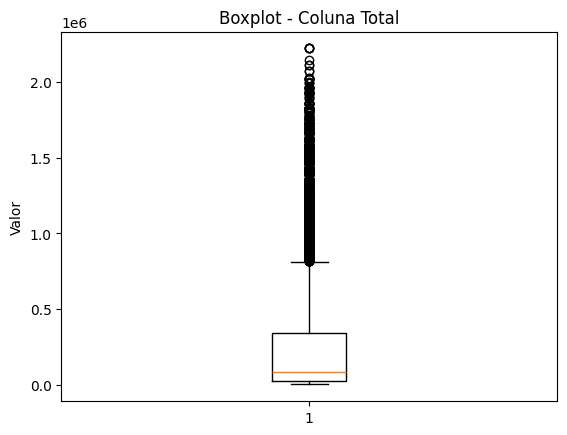

In [17]:


plt.figure()
plt.boxplot(df_vendas['total'])
plt.title('Boxplot - Coluna Total')
plt.ylabel('Valor')
plt.show()

O dataset tem um intervalo consistente de datas dos anos de 2023 a 2024 em estrutura simples, colunas bem definidas, e isso facilita a análise inicial.
Mas, aparentemente pode haver outliers na coluna "total", já que o valor máximo 2.222.973 é muito superior à média, que é de mais ou menos 263.798, isso mosta grande dispersão nos dados. E indica issopossíveis inconsistências que devem ser investigadas.
Não encontrei problemas estruturais na qualidade dos dados, como ausência de colunas ou falhas de leitura.

### Parte 2 - Análise de valores numéricos